In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from imblearn.pipeline import Pipeline
from sklearn.model_selection import KFold, RandomizedSearchCV


from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from dataclasses import dataclass
import scipy

linux_path = r"/run/media/drdrakken/Elements/Sonstiges/Programmieren/Machine Learning/csvs/titanic.csv"
windows_path = r""
df = pd.read_csv(linux_path)

In [8]:
lin_path = r"/run/media/drdrakken/Elements/Sonstiges/Programmieren/Machine Learning/csvs/titanic.csv"
windows_path = r""
df = pd.read_csv(lin_path)

In [9]:
@dataclass
class Config():
    target:str = "Survived"
    seed:int = 1234
    test_size:float = 0.2

    model_name = "Titanic_Disaster.pkl"
    model_save_path = r""
    full_model_save_path = r"" + model_name
    verbose:int = 0
    train_iterations : int = 5
    

In [10]:
config = Config()

In [11]:
class DataClass():
    def __init__(self):
        self.data = df.copy()
        self.numerical_data = self.data.select_dtypes(include = np.number).columns
        self.categorical_data = self.data.select_dtypes(exclude = np.number).columns

        self.x = self.data.drop([config.target] , axis = 1)
        self.y = self.data[config.target]

In [12]:
data = DataClass()

In [13]:
class Visualize():
    def __init__(self):
        self.data = df.copy()

    def iqr(self , iqr_col):
        q1 = self.data[iqr_col].quantile(0.75)
        q3 = self.data[iqr_col].quantile(0.25)
        iqr = q1 - q3
        return q1 , q3 , iqr
    
    def skew(self, skew_col):
        data_skewness = self.data[skew_col].skew()
        print(f"Skewness for Col:{skew_col}:->{data_skewness}")

    def plot(self):
        for vis in self.data.numerical_data:
            fig , axes = plt.subplots(3 , 1 , figsize = (10  , 10) , dpi = 200)
            q1 , q3 , _ = self.iqr(iqr_col=vis)
            mean = self.data

            sns.histplot(data = self.data , x = vis , ax = axes[0])
            axes[0].axvline(q1 , color = "green")
            axes[0].axvline(q3 , color = "red")
            axes[0].axvline(mean , color = "yellow")
            axes[0].set_title(f"Histplot for : {vis}")

            axes[1].axvline(q1 , color = "green")
            axes[1].axvline(q3 , color = "red")
            axes[1].axvline(mean , color = "yellow")
            axes[1].set_title(f"Histplot for : {vis}")

            axes[2].axvline(q1 , color = "green")
            axes[2].axvline(q3 , color = "red")
            axes[2].axvline(mean , color = "yellow")
            axes[2].set_title(f"Histplot for : {vis}")

            plt.tight_layout()
            plt.show()

In [14]:
class Preprocess(BaseEstimator , TransformerMixin):

    def fit(self , X , y = None):

        numerical_data = X.select_dtypes(include = np.number).columns
        categorical_data = X.select_dtypes(exclude = np.number).columns

        self.preprocessor = ColumnTransformer([
            ("numerical_handle" , Pipeline([
                ("numerical_imputer" , SimpleImputer(strategy = "mean")),
                ("scaler" , MinMaxScaler()),
                
            ]),numerical_data),

            ("categorical_handle" , Pipeline([
                ("categorical_imputer" , SimpleImputer(strategy="most_frequent")),
                ("encoder" , OneHotEncoder(handle_unknown="ignore" , sparse_output=False)),
            ]),categorical_data),
        ])
        self.preprocessor.fit(X)
        return self

    def transform(self , X , y = None):
        return self.preprocessor.transform(X)

In [15]:
class DataTransform():

    def fit(self, X , y = None):
        return self
    
    def transform(self, X , y = None):
        x = self.new_features(X)
        return x
    
    def new_features(self, X , y = None):
        x = X.copy()
        return x

In [16]:
def model_varianz():

    return {


        "LogisticRegression":LogisticRegression(random_state = config.seed),
        "LinearSVC":LinearSVC(random_state = config.seed),
        "DecisionTreeClassifier":DecisionTreeClassifier(random_state = config.seed),
        "RandomForestClassifier":RandomForestClassifier(random_state = config.seed),
        "XGBClassifier":XGBClassifier(random_state = config.seed),

    }

In [17]:
def custom_scoring_dict():
    return {

        "f1":"f1",
        "accuracy":"accuracy",
        "precision":"precision"

        
    }

In [18]:
def custom_paramter_grid():

    return {

        "LogisticRegression": {
            "estimator__C": scipy.stats.loguniform(1e-4, 1e2),
            "estimator__penalty": ["l2"],
            "estimator__solver": ["lbfgs"],
        },

        "DecisionTreeClassifier": {
            "estimator__criterion": ["gini", "entropy"],
            "estimator__max_depth": [None, 5, 10, 20],
            "estimator__min_samples_split": scipy.stats.randint(2, 20),
            "estimator__min_samples_leaf": scipy.stats.randint(1, 10),
        },

        "RandomForestClassifier": {
            "estimator__n_estimators": scipy.stats.randint(100, 500),
            "estimator__max_depth": scipy.stats.randint(5, 40),
            "estimator__min_samples_split": scipy.stats.randint(2, 20),
            "estimator__min_samples_leaf": scipy.stats.randint(1, 10),
            "estimator__max_features": ["sqrt", "log2"],
            "estimator__bootstrap": [True, False],
        }, 

        "LinearSVC": {
            "estimator__C": scipy.stats.loguniform(1e-4, 1e2),
            "estimator__loss": ["hinge", "squared_hinge"],
            "estimator__dual": [True],
            "estimator__max_iter": [5000, 10000],
        },

        "XGBClassifier": {
            "estimator__n_estimators": scipy.stats.randint(100, 500),
            "estimator__learning_rate": scipy.stats.loguniform(1e-3, 0.3),
            "estimator__max_depth": scipy.stats.randint(3, 10),
            "estimator__subsample": scipy.stats.uniform(0.6, 0.4),
            "estimator__colsample_bytree": scipy.stats.uniform(0.6, 0.4),
            "estimator__gamma": scipy.stats.uniform(0, 5),
            "estimator__min_child_weight": scipy.stats.randint(1, 10),
        },

    }

In [19]:
def custom_grid_search(estimator , X_train , y_train, param_grid):
    grid =  RandomizedSearchCV(estimator=estimator,
                              param_distributions=param_grid,
                              cv=config.train_iterations,
                              verbose=config.verbose,
                              n_iter=config.train_iterations,
                              scoring=custom_scoring_dict(),
                              random_state=config.seed,
                              n_jobs=-1,
                              refit="accuracy")
    
    grid.fit(X_train , y_train)
    return grid

In [20]:
def custom_pipeline(estimator , transform = False):

    steps = []
    
    if transform:
        steps.append(("Transform_performance" , DataTransform()))

    steps.append(("Base_Performance" , Preprocess()))
    steps.append(("estimator" , estimator))
    return Pipeline(steps)

In [21]:
def custom_data_validation(estimator , X_train , y_train):
    k_fold = KFold(n_splits=5 , shuffle= True , random_state = config.seed)

    return cross_validate(estimator=estimator,
                          X=X_train,
                          y=y_train,
                          verbose=config.verbose,
                          return_estimator=True,
                          return_train_score=True,
                          cv= k_fold)

In [22]:
def data_split():
    X_train , X_test , y_train , y_test = train_test_split(data.x , 
                                                           data.y,
                                                           test_size=config.test_size,
                                                           stratify = data.y,
                                                           shuffle = True)
    
    return X_train , X_test , y_train , y_test

In [23]:
class Benchmark():

    def __init__(self , Use_CV = False , Use_Grid = False):
        self.X_train , self.X_test , self.y_train , self.y_test = data_split()

        self.results = []
        self.use_cv = Use_CV
        self.use_grid_search = Use_Grid
        
        self.train()

    def train(self):

        for estimator_name , estimators in model_varianz().items():

            base_pipe = custom_pipeline(estimator=estimators ,transform=False)
            transformer_pipe = custom_pipeline(estimator=estimators , transform=True)

            if self.use_cv:

                base_cv = custom_data_validation(estimator=base_pipe , 
                                                        X_train=self.X_train,
                                                        y_train = self.y_train)                               

                transformed_cv = custom_data_validation(estimator=transformer_pipe , 
                                                        X_train=self.X_train,
                                                        y_train = self.y_train)
                    
                self.results.append({
                    "Estimator":estimators,

                    "Base_train_score":base_cv["train_score"].mean(),
                    "Base_test_score":base_cv["test_score"].mean(),
                    "Base_std_score":base_cv["test_score"].std(),

                    "Transformed_train_score":transformed_cv["train_score"].mean(),
                    "Transformed_test_score":transformed_cv["test_score"].mean(),
                    "Transformed_std_score":transformed_cv["test_score"].std(),

                })

            if self.use_grid_search:
                base_grid = custom_grid_search(estimator=base_pipe,
                                               X_train=self.X_train,
                                               y_train=self.y_train,
                                               param_grid=custom_paramter_grid()[estimator_name])
                
                transformed_grid = custom_grid_search(estimator=transformer_pipe,
                                                    X_train=self.X_train,
                                                    y_train=self.y_train,
                                                    param_grid=custom_paramter_grid()[estimator_name])
                self.results.append({
                    "Base_Best_Estimator":base_grid.best_estimator_,
                    "Transform_Best_Estimator":transformed_grid.best_estimator_,

                })
            print(self.results)

        self.plot_data()
        self.train_best_model()
        
    def plot_data(self):

        df = pd.DataFrame(self.results)

        x = np.arange(len(df))
        width = 0.35

        fig, ax = plt.subplots(figsize=(12, 6))

        ax.errorbar(
            x - width / 2,
            df["Base_test_score"],
            yerr=df["Base_std_score"],
            fmt="o-",
            capsize=5,
            linewidth=2,
            label="Ohne Transformation"
        )

        ax.errorbar(
            x + width / 2,
            df["Transformed_test_score"],
            yerr=df["Transformed_std_score"],
            fmt="s-",
            capsize=5,
            linewidth=2,
            label="Mit Transformation"
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            [type(est).__name__ for est in df["Estimator"]],
            rotation=30,
            ha="right"
        )

        ax.set_ylabel("Accuracy")
        ax.set_xlabel("Modelle")
        ax.set_title("Modellvergleich (Cross Validation)")
        ax.set_ylim(0, 1)

        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.legend()

        plt.tight_layout()
        plt.show()

    def train_best_model(self):
        self.results["Base_Best_Estimator"].fit(self.X_train , self.X_test)

/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10.

[{'Estimator': LogisticRegression(random_state=1234), 'Base_train_score': np.float64(0.9314545454545454), 'Base_test_score': np.float64(0.7986666666666667), 'Base_std_score': np.float64(0.03435759660460033), 'Transformed_train_score': np.float64(0.9314545454545454), 'Transformed_test_score': np.float64(0.7986666666666667), 'Transformed_std_score': np.float64(0.03435759660460033)}, {'Base_Best_Estimator': Pipeline(steps=[('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))]), 'Transform_Best_Estimator': Pipeline(steps=[('Transform_performance',
                 <__main__.DataTransform object at 0x7f82559da580>),
                ('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))])}]


/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hom

[{'Estimator': LogisticRegression(random_state=1234), 'Base_train_score': np.float64(0.9314545454545454), 'Base_test_score': np.float64(0.7986666666666667), 'Base_std_score': np.float64(0.03435759660460033), 'Transformed_train_score': np.float64(0.9314545454545454), 'Transformed_test_score': np.float64(0.7986666666666667), 'Transformed_std_score': np.float64(0.03435759660460033)}, {'Base_Best_Estimator': Pipeline(steps=[('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))]), 'Transform_Best_Estimator': Pipeline(steps=[('Transform_performance',
                 <__main__.DataTransform object at 0x7f82559da580>),
                ('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))])}, {'

/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hom

[{'Estimator': LogisticRegression(random_state=1234), 'Base_train_score': np.float64(0.9314545454545454), 'Base_test_score': np.float64(0.7986666666666667), 'Base_std_score': np.float64(0.03435759660460033), 'Transformed_train_score': np.float64(0.9314545454545454), 'Transformed_test_score': np.float64(0.7986666666666667), 'Transformed_std_score': np.float64(0.03435759660460033)}, {'Base_Best_Estimator': Pipeline(steps=[('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))]), 'Transform_Best_Estimator': Pipeline(steps=[('Transform_performance',
                 <__main__.DataTransform object at 0x7f82559da580>),
                ('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))])}, {'

/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hom

[{'Estimator': LogisticRegression(random_state=1234), 'Base_train_score': np.float64(0.9314545454545454), 'Base_test_score': np.float64(0.7986666666666667), 'Base_std_score': np.float64(0.03435759660460033), 'Transformed_train_score': np.float64(0.9314545454545454), 'Transformed_test_score': np.float64(0.7986666666666667), 'Transformed_std_score': np.float64(0.03435759660460033)}, {'Base_Best_Estimator': Pipeline(steps=[('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))]), 'Transform_Best_Estimator': Pipeline(steps=[('Transform_performance',
                 <__main__.DataTransform object at 0x7f82559da580>),
                ('Base_Performance', Preprocess()),
                ('estimator',
                 LogisticRegression(C=np.float64(0.5403219694006519),
                                    penalty='l2', random_state=1234))])}, {'

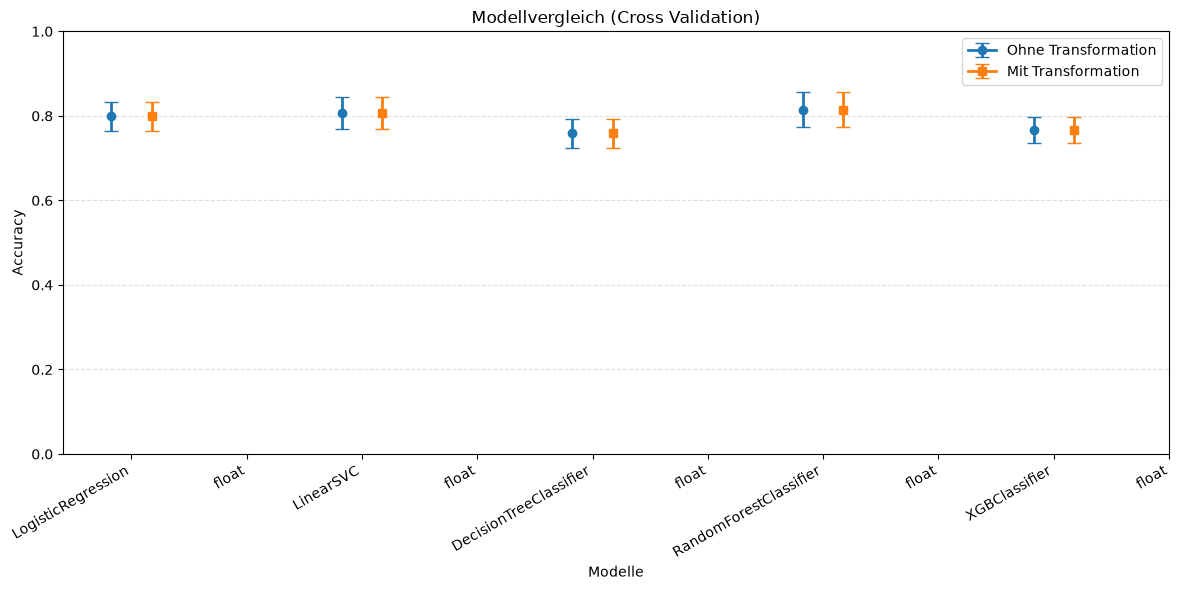

TypeError: list indices must be integers or slices, not str

In [24]:
Benchmark(Use_CV = True , Use_Grid = True)